In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
import pandas as pd
df = pd.read_csv('/content/OnlineRetail.csv', encoding="ISO-8859-1")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
df = df.dropna(subset=['CustomerID'])

In [9]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [10]:
df.duplicated().sum()

np.int64(5225)

In [11]:
df = df.drop_duplicates()

In [12]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [15]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [16]:
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [17]:
df = df[df['Quantity'] > 0]

In [18]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [19]:
df = df[df['UnitPrice'] > 0]

In [20]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [22]:
df.to_csv("Cleaned_Online_Retail.csv", index=False)

In [23]:
from google.colab import files

files.download("Cleaned_Online_Retail.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
df.shape

(392692, 9)

In [25]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [27]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalAmount,0


In [28]:
df = df.dropna(
    subset=['CustomerID']
)

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df = df.drop_duplicates()

In [31]:
df = df[
    ~df['InvoiceNo']
    .astype(str)
    .str.startswith('C')
]

In [32]:
df = df[
    df['Quantity'] > 0
]

In [33]:
df = df[
    df['UnitPrice'] > 0
]

In [34]:
df['Revenue'] = (
    df['Quantity']
    *
    df['UnitPrice']
)

In [35]:
df['Revenue'].describe()

,Revenue
count,392692.000000
mean,22.631500
std,311.099224
min,0.001000
25%,4.950000
50%,12.450000
75%,19.800000
max,168469.600000


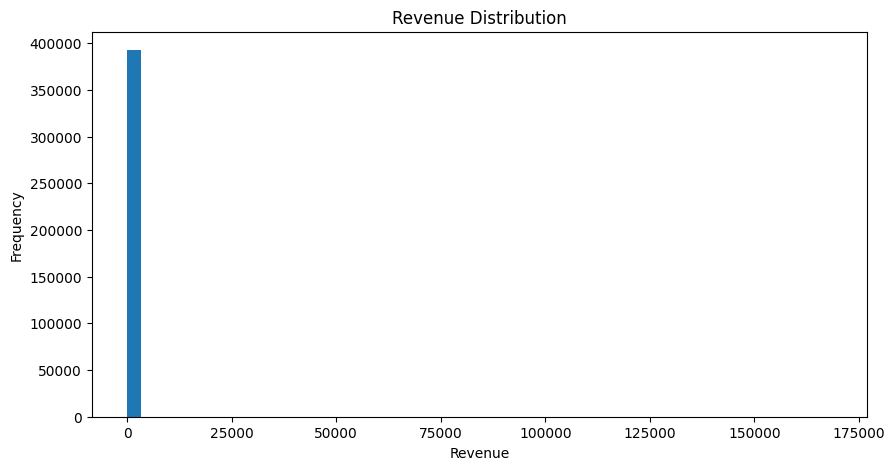

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    df['Revenue'],
    bins=50
)

plt.title(
    'Revenue Distribution'
)

plt.xlabel('Revenue')

plt.ylabel('Frequency')

plt.show()

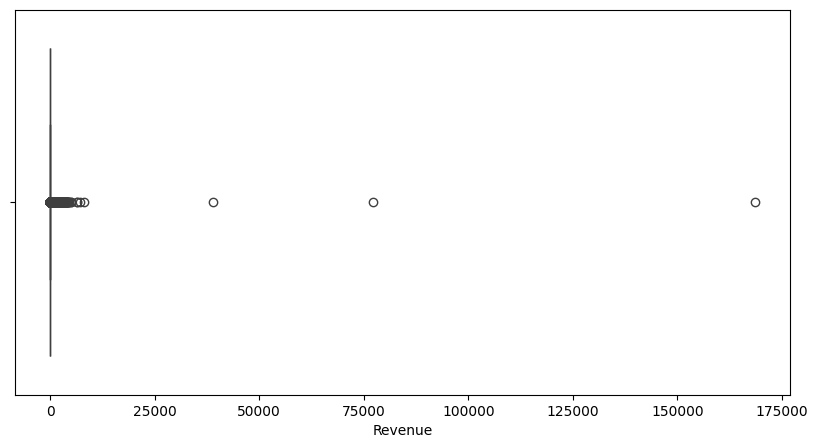

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Revenue']
)

plt.show()

In [38]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate']
)

In [39]:
df['Month'] = (
    df['InvoiceDate']
    .dt.month
)

In [40]:
monthly_sales = (
    df.groupby('Month')
      ['Revenue']
      .sum()
)

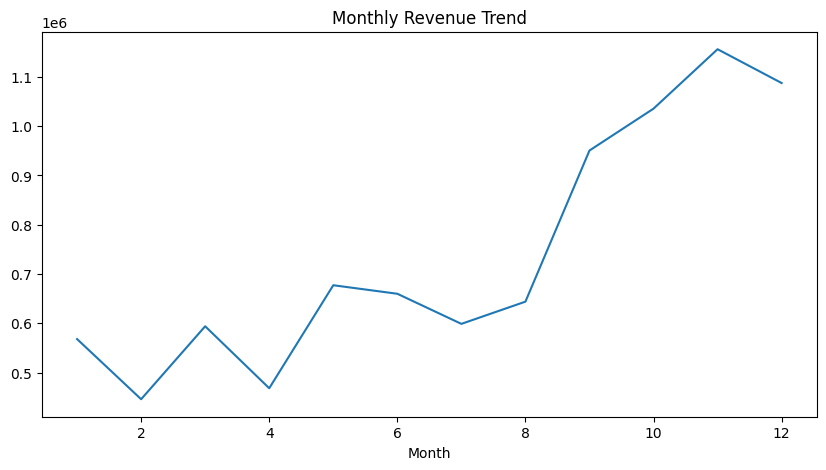

In [41]:
monthly_sales.plot(
    kind='line',
    figsize=(10,5)
)

plt.title(
    'Monthly Revenue Trend'
)

plt.show()

In [42]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [43]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [44]:
print(snapshot_date)

2011-12-10 12:50:00


In [45]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [46]:
rfm.head()

,InvoiceDate,InvoiceNo,Revenue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [47]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

In [48]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [49]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


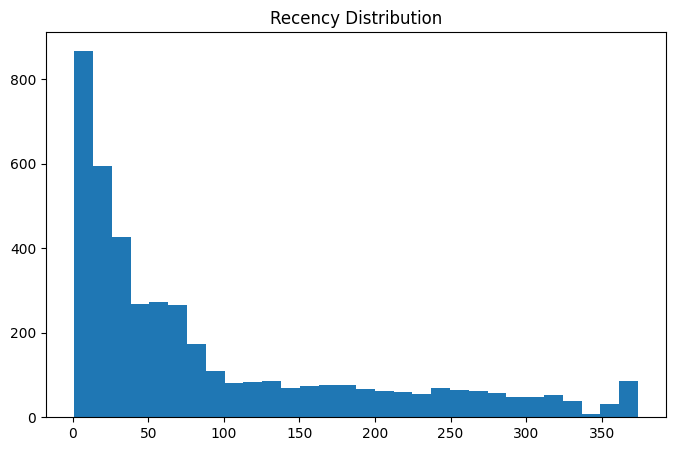

In [50]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Recency'], bins=30)
plt.title('Recency Distribution')
plt.show()

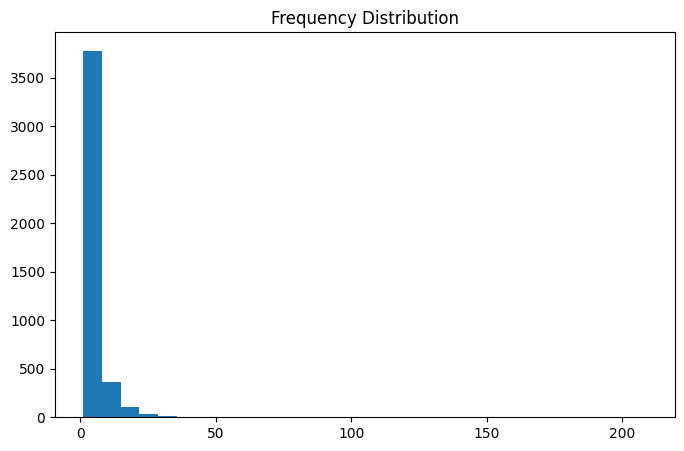

In [51]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Frequency'], bins=30)
plt.title('Frequency Distribution')
plt.show()

In [52]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [53]:
# rfm['Recency'] = (reference_date - pd.to_timedelta(rfm['Recency'], unit='D')).dt.days
# This line is not needed as Recency was already correctly calculated.

In [54]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [55]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [56]:
pd.qcut(rfm['Recency'], q=4)

,Recency
CustomerID,
12346.0,"(142.0, 374.0]"
12347.0,"(0.999, 18.0]"
12348.0,"(51.0, 142.0]"
12349.0,"(18.0, 51.0]"
12350.0,"(142.0, 374.0]"
...,...
18280.0,"(142.0, 374.0]"
18281.0,"(142.0, 374.0]"
18282.0,"(0.999, 18.0]"


In [57]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5,4,3,2,1]
)

In [58]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

In [59]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    q=5,
    labels=[1,2,3,4,5]
)

In [60]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [61]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [62]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [63]:
def customer_segment(row):

    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'

    elif row['R_Score'] >= 3 and row['F_Score'] >= 4:
        return 'Loyal Customers'

    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'Potential Loyalists'

    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'

    else:
        return 'Lost Customers'

In [64]:
rfm['Customer_Segment'] = rfm.apply(customer_segment, axis=1)

In [65]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,Lost Customers
12347.0,2,7,4310.00,5,5,5,555,Champions
12348.0,75,4,1797.24,2,4,4,244,At Risk
12349.0,19,1,1757.55,4,1,4,414,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,Lost Customers


In [66]:
rfm['Customer_Segment'].value_counts()

,count
Customer_Segment,
Lost Customers,1916
Champions,957
At Risk,643
Loyal Customers,503
Potential Loyalists,319


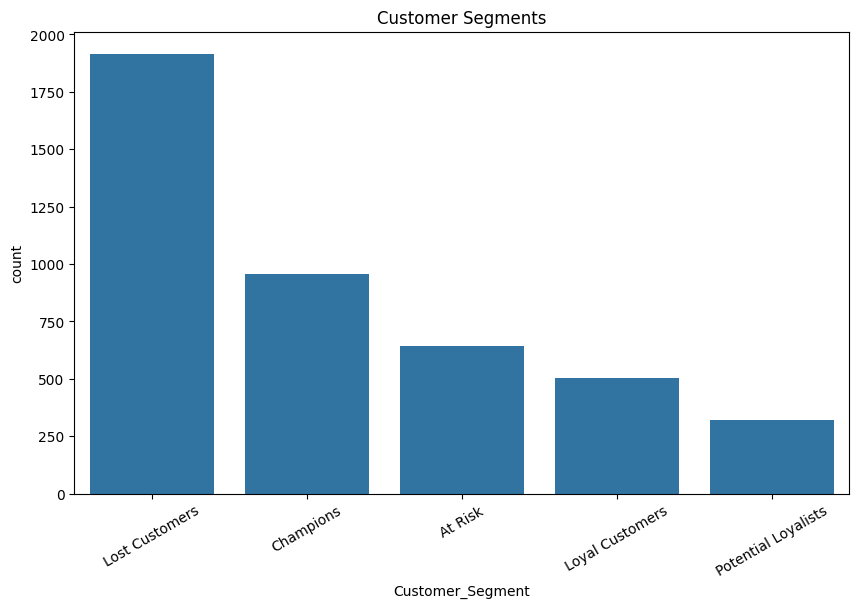

In [67]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x='Customer_Segment',
    order=rfm['Customer_Segment'].value_counts().index
)

plt.title("Customer Segments")

plt.xticks(rotation=30)

plt.show()

In [68]:
rfm['Churn'] = rfm['Recency'].apply(
    lambda x: 1 if x > 90 else 0
)

In [69]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment,Churn
CustomerID,,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,Lost Customers,1
12347.0,2,7,4310.00,5,5,5,555,Champions,0
12348.0,75,4,1797.24,2,4,4,244,At Risk,0
12349.0,19,1,1757.55,4,1,4,414,Potential Loyalists,0
12350.0,310,1,334.40,1,1,2,112,Lost Customers,1


In [70]:
rfm['Churn'].value_counts()

,count
Churn,
0,2889
1,1449


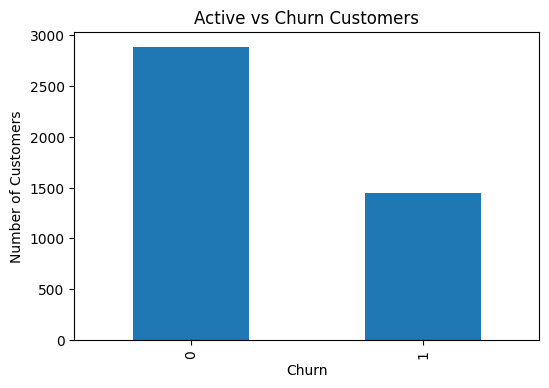

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

rfm['Churn'].value_counts().plot(
    kind='bar'
)

plt.title("Active vs Churn Customers")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

In [72]:
X = rfm[['Frequency', 'Monetary']]

In [73]:
y = rfm['Churn']

In [74]:
X.head()

,Frequency,Monetary
CustomerID,,
12346.0,1,77183.60
12347.0,7,4310.00
12348.0,4,1797.24
12349.0,1,1757.55
12350.0,1,334.40


In [75]:
y.head()

,Churn
CustomerID,
12346.0,1
12347.0,0
12348.0,0
12349.0,0
12350.0,1


In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [78]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (3470, 2)
Testing Features : (868, 2)
Training Labels  : (3470,)
Testing Labels   : (868,)


In [79]:
from sklearn.linear_model import LogisticRegression

In [80]:
log_model = LogisticRegression()

In [81]:
log_model.fit(X_train, y_train)

LogisticRegression()

In [82]:
y_pred = log_model.predict(X_test)

In [83]:
print(y_pred[:20])

[1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 0 1 1]


In [84]:
probability = log_model.predict_proba(X_test)

probability[:5]

array([[0.47599418, 0.52400582],
       [0.59190931, 0.40809069],
       [0.59274233, 0.40725767],
       [0.78728634, 0.21271366],
       [0.47793341, 0.52206659]])

In [85]:
from sklearn.metrics import confusion_matrix

In [86]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[449 112]
 [137 170]]


In [87]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

0.7131336405529954


In [88]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78       561
           1       0.60      0.55      0.58       307

    accuracy                           0.71       868
   macro avg       0.68      0.68      0.68       868
weighted avg       0.71      0.71      0.71       868



In [89]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [90]:
y_prob = log_model.predict_proba(X_test)[:,1]

In [91]:
fpr, tpr, thresholds = roc_curve(y_test,y_prob)

In [92]:
auc = roc_auc_score(y_test,y_prob)

print(auc)

0.7646913666266033


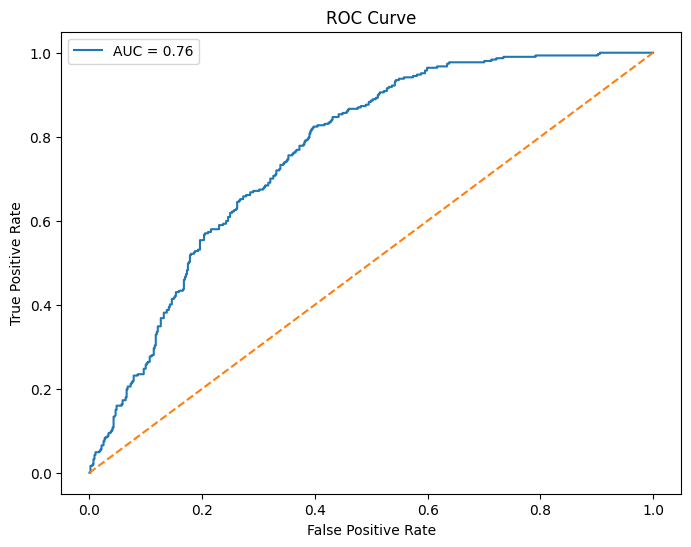

In [93]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [94]:
from sklearn.tree import DecisionTreeClassifier

In [95]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42,
    max_depth=4
)

In [96]:
criterion='entropy'

In [97]:
dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [98]:
dt_pred = dt_model.predict(X_test)

In [99]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(f"Decision Tree Accuracy: {dt_accuracy}")

dt_prob = dt_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(
    y_test,
    dt_prob
)

print(f"Decision Tree AUC: {auc}")

Decision Tree Accuracy: 0.6935483870967742
Decision Tree AUC: 0.7685873875756994


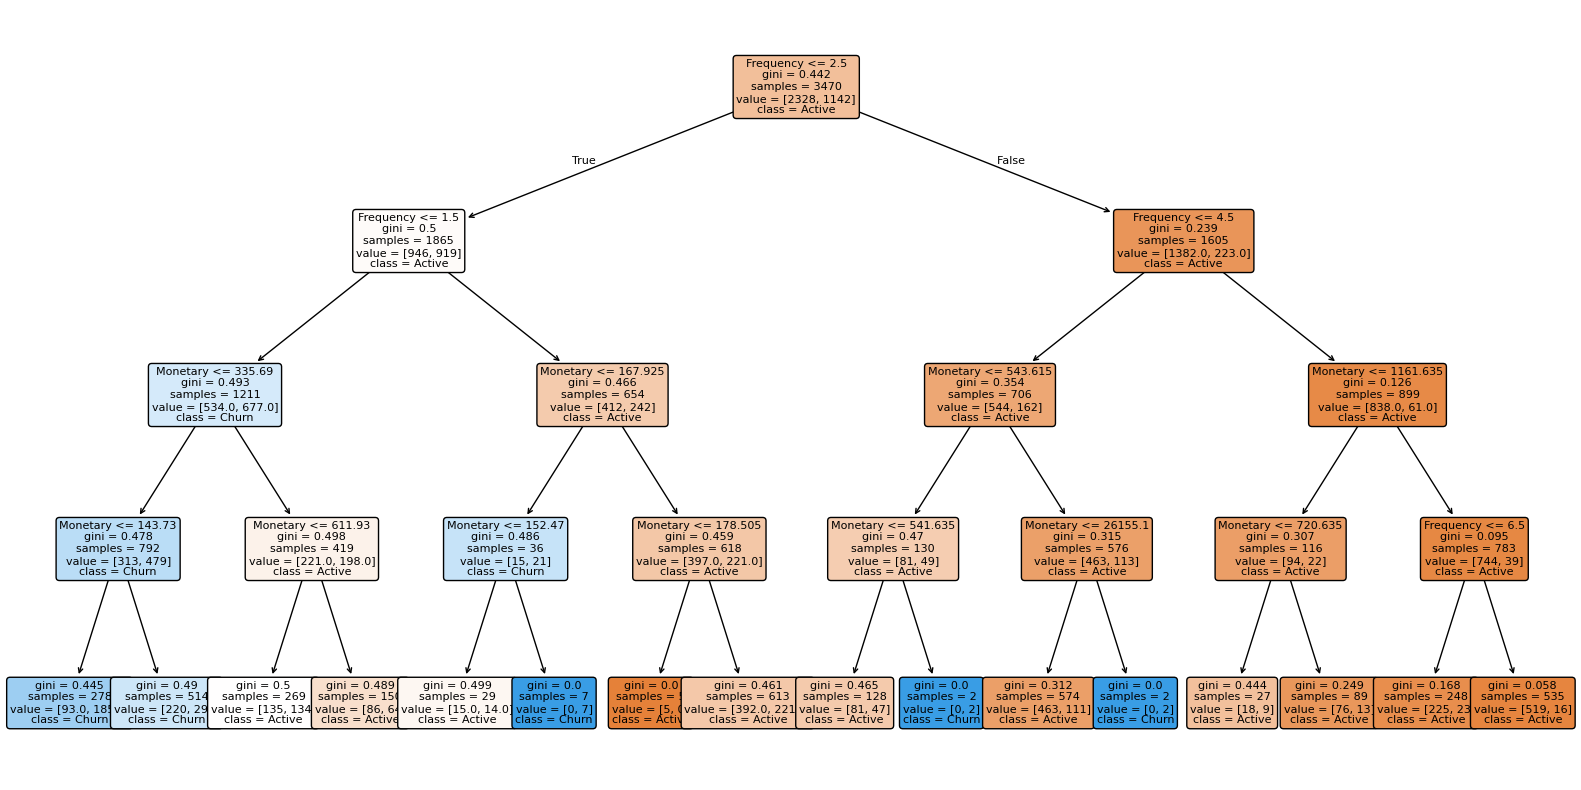

In [100]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Active","Churn"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [101]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)


,Feature,Importance
0,Frequency,0.875946
1,Monetary,0.124054


In [102]:
from sklearn.ensemble import RandomForestClassifier

In [103]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [104]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=5, random_state=42)

In [105]:
rf_pred = rf_model.predict(X_test)

In [106]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Accuracy:", rf_accuracy)

Accuracy: 0.7004608294930875


In [107]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print(rf_cm)

[[477  84]
 [176 131]]


In [108]:
rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [109]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("AUC:", rf_auc)

AUC: 0.7701608923107294


In [110]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
1   Monetary    0.541964
0  Frequency    0.458036


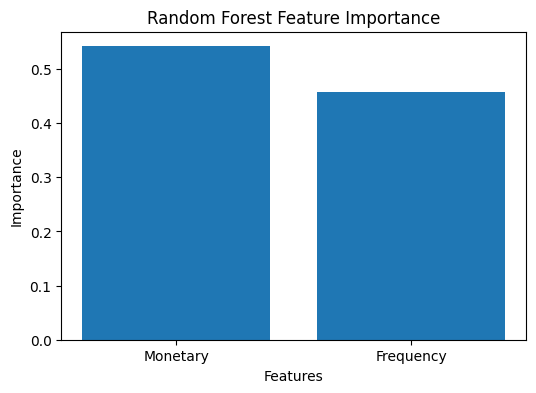

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [112]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Assign Logistic Regression metrics from existing variables or recalculate
log_accuracy = accuracy
log_precision = precision_score(y_test, y_pred)
log_recall = recall_score(y_test, y_pred)
log_f1 = f1_score(y_test, y_pred)
log_auc = roc_auc_score(y_test, y_prob) # Recalculate LR AUC using its probabilities

# Assign Decision Tree metrics
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob) # dt_prob was used to calculate the last 'auc' value

# Assign Random Forest metrics
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
# rf_auc is already defined from cell jokCq_oHfP_l

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        log_precision,
        dt_precision,
        rf_precision
    ],

    "Recall":[
        log_recall,
        dt_recall,
        rf_recall
    ],

    "F1 Score":[
        log_f1,
        dt_f1,
        rf_f1
    ],

    "AUC":[
        log_auc,
        dt_auc,
        rf_auc
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.713134,0.602837,0.553746,0.577250,0.764691
1,Decision Tree,0.693548,0.610811,0.368078,0.459350,0.768587
2,Random Forest,0.700461,0.609302,0.426710,0.501916,0.770161


In [113]:
rfm.to_csv("Customer_Analytics.csv", index=True)

In [114]:
rfm.to_csv("Customer_Analytics.csv", index=True)

In [115]:
comparison.to_csv("Model_Comparison.csv", index=False)
